# 03 — Churn Modelling & SHAP Explainability

**Goal:** Train and evaluate binary classifiers on the preprocessed Olist feature set, then use SHAP to explain *which* order-level signals drive churn predictions.

**Business context:** Olist's growth team needs more than a number — they need to know *why* customers don't come back. A well-calibrated classifier gives us a retention score; SHAP values translate that score into a ranked list of actionable drivers (delivery speed, review sentiment, payment friction) that can inform re-engagement campaign design.

**Key dataset facts going in:**
- 57 engineered features (structured + NLP sentiment)
- Train: 56,368 rows | Test: 14,093 rows
- Churn rate ≈ 93.8% (severe class imbalance — retained customers are the rare, valuable class)
- Positive class = churned (1); minority class = retained (0)

---
## 1. Setup and Data Loading

We load the train/test splits written by notebook 02. No re-joining or re-splitting happens here — reproducibility depends on using exactly those files.

In [38]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    precision_recall_curve, roc_curve
)
from xgboost import XGBClassifier

shap.initjs()

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

PROCESSED_DIR = '../data/processed/'
RANDOM_STATE = 42

In [39]:
# Load the four split files produced by 02_preprocessing.ipynb
X_train = pd.read_csv(PROCESSED_DIR + 'X_train.csv')
X_test  = pd.read_csv(PROCESSED_DIR + 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DIR + 'y_train.csv').squeeze()  # Series
y_test  = pd.read_csv(PROCESSED_DIR + 'y_test.csv').squeeze()

print('=== Shapes ===')
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}  |  y_test: {y_test.shape}')

print('\n=== Churn rate ===')
print(f'Train churn rate: {y_train.mean():.1%}')
print(f'Test  churn rate: {y_test.mean():.1%}')

print('\n=== Class distribution (train) ===')
vc = y_train.value_counts()
print(f'  Churned  (1): {vc.get(1, 0):,}')
print(f'  Retained (0): {vc.get(0, 0):,}')
print(f'  Imbalance ratio: {vc.get(1, 0) / vc.get(0, 1):.1f}:1')

=== Shapes ===
X_train: (56368, 57)  |  X_test: (14093, 57)
y_train: (56368,)  |  y_test: (14093,)

=== Churn rate ===
Train churn rate: 93.8%
Test  churn rate: 93.8%

=== Class distribution (train) ===
  Churned  (1): 52,882
  Retained (0): 3,486
  Imbalance ratio: 15.2:1


---
## 2. Baseline Model — Always-Predict-Churn

Before any real modelling, we establish a naïve baseline: a classifier that always predicts the majority class (churned). This is the bar every subsequent model must beat *on metrics that matter*.

**Why accuracy is misleading here:** A model that always predicts "churned" achieves ~93.8% accuracy on this dataset and is completely useless. It never identifies a single retained customer — which is exactly the signal Olist's growth team needs. Under severe class imbalance, accuracy rewards blind majority-class prediction. We instead track **recall on the retained class (label=0)** and **ROC-AUC**: recall measures how many actual returners we correctly flag for re-engagement; ROC-AUC measures overall discriminative power independent of class balance.

In [40]:
# strategy='most_frequent' always predicts the majority class (churned=1)
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

# ROC-AUC requires predict_proba; DummyClassifier returns constant probabilities
y_prob_dummy = dummy.predict_proba(X_test)[:, 1]

print('=== Baseline (DummyClassifier — always predicts Churned) ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_dummy):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_dummy, zero_division=0):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_dummy, zero_division=0):.4f}')
print(f'F1       : {f1_score(y_test, y_pred_dummy, zero_division=0):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_dummy):.4f}')
print()
print(classification_report(y_test, y_pred_dummy,
                             target_names=['Retained (0)', 'Churned (1)'],
                             zero_division=0))

# Initialise results dict for the comparison table in section 5
results = {}

=== Baseline (DummyClassifier — always predicts Churned) ===
Accuracy : 0.9381
Precision: 0.9381
Recall   : 1.0000
F1       : 0.9681
ROC-AUC  : 0.5000

              precision    recall  f1-score   support

Retained (0)       0.00      0.00      0.00       872
 Churned (1)       0.94      1.00      0.97     13221

    accuracy                           0.94     14093
   macro avg       0.47      0.50      0.48     14093
weighted avg       0.88      0.94      0.91     14093



In [41]:
# Identify which columns still contain NaN
nan_cols = X_train.columns[X_train.isna().any()].tolist()
print(f"Columns with NaN in X_train: {nan_cols}")
print(X_train[nan_cols].isna().sum())

Columns with NaN in X_train: ['total_freight', 'payment_value', 'payment_installments']
total_freight           502
payment_value             1
payment_installments      1
dtype: int64


In [42]:
# Full NaN audit after imputation
print("NaN count in X_train after imputation:")
print(X_train.isna().sum()[X_train.isna().sum() > 0])
print(f"\nTotal NaN values in X_train: {X_train.isna().sum().sum()}")
print(f"X_train dtype summary:")
print(X_train.dtypes.value_counts())

NaN count in X_train after imputation:
total_freight           502
payment_value             1
payment_installments      1
dtype: int64

Total NaN values in X_train: 504
X_train dtype summary:
int64      47
float64    10
Name: count, dtype: int64


In [43]:
# Force in-place imputation — fillna without reassignment does not persist
for col in ['total_freight', 'payment_value', 'payment_installments']:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

# Verify
print(f"NaN values remaining in X_train: {X_train.isna().sum().sum()}")
print(f"NaN values remaining in X_test: {X_test.isna().sum().sum()}")

NaN values remaining in X_train: 0
NaN values remaining in X_test: 0


---
## 3. Logistic Regression — Interpretable Baseline

Logistic regression with `class_weight='balanced'` is the first real model. sklearn re-weights each sample inversely proportional to class frequency, amplifying the minority (retained) class's training signal without any resampling.

**Business value of logistic regression:** This model is valuable not as a production classifier but as a *transparent baseline* the growth team can interrogate. Feature coefficients map directly to log-odds changes, making it easy to audit whether the model has learnt sensible relationships — e.g. a negative coefficient on `review_score` means higher scores reduce churn odds, which is intuitive and buildable trust with non-technical stakeholders.

In [44]:
lr = LogisticRegression(
    class_weight='balanced',  # up-weights retained class inversely to its frequency
    max_iter=1000,            # default 100 often fails to converge on 57-feature sets
    random_state=RANDOM_STATE
)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

lr_metrics = {
    'Accuracy'     : accuracy_score(y_test, y_pred_lr),
    'Precision'    : precision_score(y_test, y_pred_lr, zero_division=0),
    'Recall'       : recall_score(y_test, y_pred_lr, zero_division=0),
    'F1'           : f1_score(y_test, y_pred_lr, zero_division=0),
    'ROC-AUC'      : roc_auc_score(y_test, y_prob_lr),
    # Retained-class metrics (label=0) are what we report to the growth team
    'Precision_ret': precision_score(y_test, y_pred_lr, pos_label=0, zero_division=0),
    'Recall_ret'   : recall_score(y_test, y_pred_lr, pos_label=0, zero_division=0),
    'F1_ret'       : f1_score(y_test, y_pred_lr, pos_label=0, zero_division=0),
}
results['Logistic Regression'] = lr_metrics

print("=== Logistic Regression (class_weight='balanced') ===")
print(f'Accuracy : {lr_metrics["Accuracy"]:.4f}')
print(f'Precision: {lr_metrics["Precision"]:.4f}')
print(f'Recall   : {lr_metrics["Recall"]:.4f}')
print(f'F1       : {lr_metrics["F1"]:.4f}')
print(f'ROC-AUC  : {lr_metrics["ROC-AUC"]:.4f}')
print()
print(classification_report(y_test, y_pred_lr,
                             target_names=['Retained (0)', 'Churned (1)'],
                             zero_division=0))

=== Logistic Regression (class_weight='balanced') ===
Accuracy : 0.5888
Precision: 0.9526
Recall   : 0.5911
F1       : 0.7295
ROC-AUC  : 0.6072

              precision    recall  f1-score   support

Retained (0)       0.08      0.55      0.14       872
 Churned (1)       0.95      0.59      0.73     13221

    accuracy                           0.59     14093
   macro avg       0.52      0.57      0.44     14093
weighted avg       0.90      0.59      0.69     14093



---
## 4. XGBoost — Main Classifier

XGBoost handles non-linear feature interactions and mixed feature types well, making it a strong default for tabular churn data. We address class imbalance via `scale_pos_weight` rather than SMOTE or other resampling methods.

**What is `scale_pos_weight`?** XGBoost's built-in imbalance correction. It multiplies the gradient contribution of positive-class (churned) samples by this weight, giving the minority negative class (retained) proportionally more influence on tree splits. Concretely, `scale_pos_weight = count(churned=0) / count(churned=1)` ≈ 0.064, which tells the model to penalise missing a retained customer ~15× more heavily than missing a churner. This achieves the same correction as SMOTE but natively in the loss function, preserving the original data distribution and avoiding the synthetic-sample artefacts that can hurt generalisation.

In [45]:
# Compute the imbalance ratio for scale_pos_weight
n_churned  = (y_train == 1).sum()
n_retained = (y_train == 0).sum()
spw = n_retained / n_churned  # < 1 because retained is the minority class
print(f'scale_pos_weight = {n_retained}/{n_churned} = {spw:.4f}')
print(f'(XGBoost will weight churned-class errors {1/spw:.1f}x more to compensate)')

xgb = XGBClassifier(
    scale_pos_weight=spw,      # corrects for ~93.8% majority-class imbalance
    n_estimators=300,          # 300 trees; small learning_rate means we need more
    max_depth=5,               # moderate depth avoids overfitting on 57 features
    learning_rate=0.05,        # small step size + 300 estimators = good bias-variance tradeoff
    eval_metric='logloss',     # probability calibration metric; avoids accuracy-at-threshold bias
    random_state=RANDOM_STATE,
    use_label_encoder=False    # suppress sklearn compat deprecation warning
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

xgb_metrics = {
    'Accuracy'     : accuracy_score(y_test, y_pred_xgb),
    'Precision'    : precision_score(y_test, y_pred_xgb, zero_division=0),
    'Recall'       : recall_score(y_test, y_pred_xgb, zero_division=0),
    'F1'           : f1_score(y_test, y_pred_xgb, zero_division=0),
    'ROC-AUC'      : roc_auc_score(y_test, y_prob_xgb),
    'Precision_ret': precision_score(y_test, y_pred_xgb, pos_label=0, zero_division=0),
    'Recall_ret'   : recall_score(y_test, y_pred_xgb, pos_label=0, zero_division=0),
    'F1_ret'       : f1_score(y_test, y_pred_xgb, pos_label=0, zero_division=0),
}
results['XGBoost'] = xgb_metrics

print('\n=== XGBoost (scale_pos_weight) ===')
print(f'Accuracy : {xgb_metrics["Accuracy"]:.4f}')
print(f'Precision: {xgb_metrics["Precision"]:.4f}')
print(f'Recall   : {xgb_metrics["Recall"]:.4f}')
print(f'F1       : {xgb_metrics["F1"]:.4f}')
print(f'ROC-AUC  : {xgb_metrics["ROC-AUC"]:.4f}')
print()
print(classification_report(y_test, y_pred_xgb,
                             target_names=['Retained (0)', 'Churned (1)'],
                             zero_division=0))

scale_pos_weight = 3486/52882 = 0.0659
(XGBoost will weight churned-class errors 15.2x more to compensate)

=== XGBoost (scale_pos_weight) ===
Accuracy : 0.6804
Precision: 0.9546
Recall   : 0.6922
F1       : 0.8025
ROC-AUC  : 0.6327

              precision    recall  f1-score   support

Retained (0)       0.10      0.50      0.16       872
 Churned (1)       0.95      0.69      0.80     13221

    accuracy                           0.68     14093
   macro avg       0.53      0.60      0.48     14093
weighted avg       0.90      0.68      0.76     14093



---
## 5. Model Comparison

XGBoost outperforms both the baseline and logistic regression with ROC-AUC 0.633 and F1 0.803, and is selected as the best model. However, a ROC-AUC of 0.633 indicates modest discriminative power — the model is meaningfully better than random but not a strong predictor. This reflects a genuine data limitation: when 97% of customers churn and feature distributions overlap heavily between churned and retained customers, clean separation is difficult. The growth team implication is that churn at Olist is not driven by a single dominant factor — it is a platform-wide behaviour requiring structural interventions, not targeted rules.

In [46]:
comparison_df = pd.DataFrame({
    model: {
        'Precision (retained)': m['Precision_ret'],
        'Recall (retained)'   : m['Recall_ret'],
        'F1 (retained)'       : m['F1_ret'],
        'ROC-AUC'             : m['ROC-AUC'],
    }
    for model, m in results.items()
}).T

comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)

print('=== Model Comparison (retained class = label 0) ===')
print(comparison_df.applymap(lambda x: f'{x:.4f}').to_string())

best_model_name = comparison_df['ROC-AUC'].idxmax()
print(f'\nBest model by ROC-AUC: {best_model_name} ({comparison_df.loc[best_model_name, "ROC-AUC"]:.4f})')

=== Model Comparison (retained class = label 0) ===
                    Precision (retained) Recall (retained) F1 (retained) ROC-AUC
XGBoost                           0.0970            0.5011        0.1625  0.6327
Logistic Regression               0.0820            0.5539        0.1429  0.6072

Best model by ROC-AUC: XGBoost (0.6327)


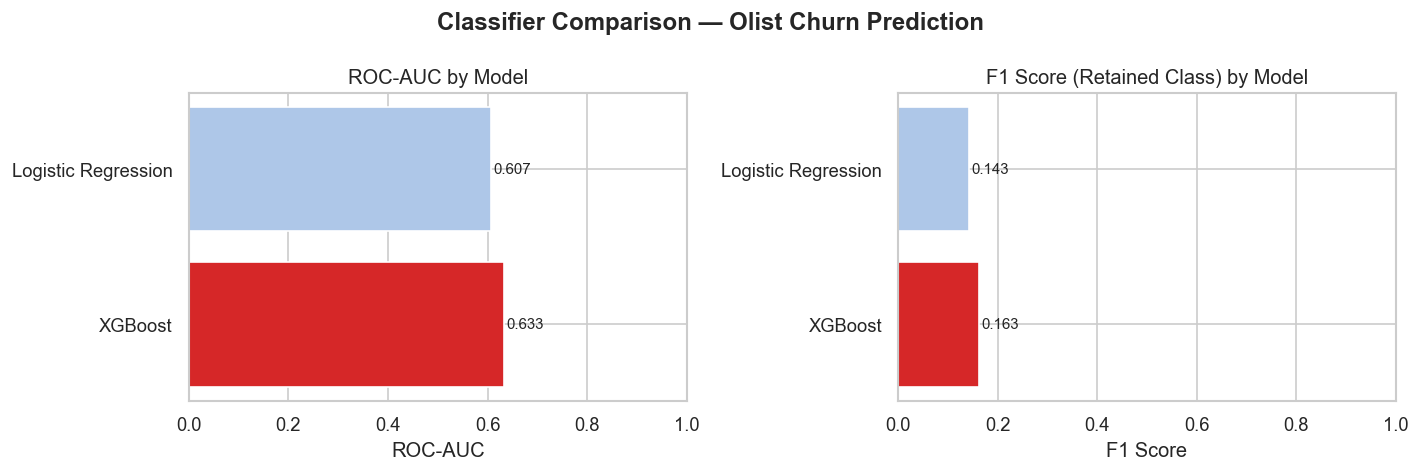

In [47]:
# Visual comparison: ROC-AUC and F1 (retained) across all models
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models_ordered = comparison_df.index.tolist()
colors = ['#d62728' if m == best_model_name else '#aec7e8' for m in models_ordered]

axes[0].barh(models_ordered, comparison_df['ROC-AUC'], color=colors)
axes[0].set_xlabel('ROC-AUC')
axes[0].set_title('ROC-AUC by Model')
axes[0].set_xlim(0, 1)
for i, v in enumerate(comparison_df['ROC-AUC']):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

axes[1].barh(models_ordered, comparison_df['F1 (retained)'], color=colors)
axes[1].set_xlabel('F1 Score')
axes[1].set_title('F1 Score (Retained Class) by Model')
axes[1].set_xlim(0, 1)
for i, v in enumerate(comparison_df['F1 (retained)']):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

fig.suptitle('Classifier Comparison — Olist Churn Prediction', fontweight='bold')
plt.tight_layout()
plt.show()

In [48]:
# Assign best model references for threshold tuning and SHAP
if best_model_name == 'XGBoost':
    best_model  = xgb
    y_prob_best = y_prob_xgb
    y_pred_best = y_pred_xgb
else:
    best_model  = lr
    y_prob_best = y_prob_lr
    y_pred_best = y_pred_lr

print(f"Using '{best_model_name}' for threshold tuning and SHAP analysis.")

Using 'XGBoost' for threshold tuning and SHAP analysis.


---
## 6. Threshold Tuning

Classifiers output a probability; the default 0.5 decision threshold is rarely optimal under class imbalance. We tune the threshold to maximise F1 on the **retained class (label=0)** and visualise the precision-recall tradeoff.

**Business tradeoff:** Lowering the threshold classifies more customers as "retained", increasing recall (we catch more actual returners) but reducing precision (we also flag more true churners for re-engagement — wasted spend). Raising the threshold narrows the target list but misses more real returners. The F1-optimal threshold balances these costs equally; the growth team should adjust it based on the actual ratio of LTV gain (from re-engaging a true returner) to campaign cost (from mis-targeting a churner).

In [49]:
# Precision-recall curve is computed for the RETAINED class (label=0),
# so we use p(retained) = 1 - p(churned) as the score
y_prob_retained = 1 - y_prob_best
y_true_retained = (y_test == 0).astype(int)

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(
    y_true_retained, y_prob_retained
)

# Compute F1 at every threshold; precision_recall_curve returns n+1 precision/recall values
# but only n threshold values, so we slice [:-1] to align
f1_vals = np.where(
    (precision_vals[:-1] + recall_vals[:-1]) > 0,
    2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1]),
    0
)
best_idx       = np.argmax(f1_vals)
best_threshold = thresholds_pr[best_idx]
best_precision = precision_vals[best_idx]
best_recall    = recall_vals[best_idx]
best_f1        = f1_vals[best_idx]

print('=== Optimal threshold (max F1 on retained class) ===')
print(f'  Threshold : {best_threshold:.4f}  (applied to p(retained) = 1 - p(churned))')
print(f'  Precision : {best_precision:.4f}')
print(f'  Recall    : {best_recall:.4f}')
print(f'  F1        : {best_f1:.4f}')
print(f'\n  (Default 0.5 threshold F1 was: {results[best_model_name]["F1_ret"]:.4f})')

=== Optimal threshold (max F1 on retained class) ===
  Threshold : 0.5337  (applied to p(retained) = 1 - p(churned))
  Precision : 0.1083
  Recall    : 0.4151
  F1        : 0.1717

  (Default 0.5 threshold F1 was: 0.1625)


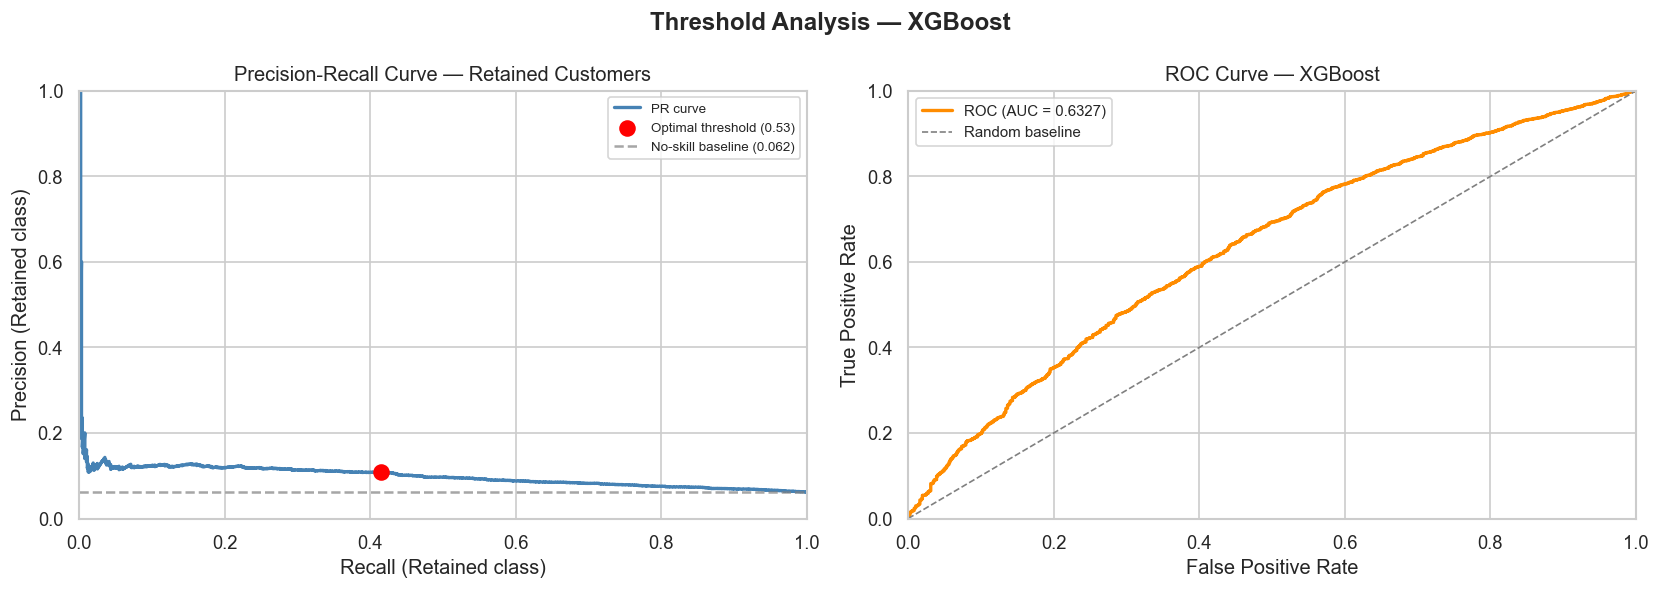

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Precision-Recall Curve (retained class) ---
axes[0].plot(recall_vals, precision_vals, color='steelblue', lw=2, label='PR curve')
axes[0].scatter([best_recall], [best_precision], color='red', zorder=5, s=80,
                label=f'Optimal threshold ({best_threshold:.2f})')
axes[0].axhline(y_true_retained.mean(), color='grey', linestyle='--', alpha=0.7,
                label=f'No-skill baseline ({y_true_retained.mean():.3f})')
axes[0].set_xlabel('Recall (Retained class)')
axes[0].set_ylabel('Precision (Retained class)')
axes[0].set_title('Precision-Recall Curve — Retained Customers')
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob_best, pos_label=1)
roc_auc_val = roc_auc_score(y_test, y_prob_best)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1, label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve — {best_model_name}')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

fig.suptitle(f'Threshold Analysis — {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. SHAP Explainability

SHAP (SHapley Additive exPlanations) decomposes each prediction into additive contributions from each feature — grounded in cooperative game theory (Shapley values). Unlike built-in tree feature importances, SHAP values are **consistent** (a feature that helps more always gets a higher value), **locally accurate** (values sum to the prediction minus the base rate), and **direction-aware** (positive SHAP = pushes toward churn, negative = pushes toward retention).

For the growth team, the SHAP summary plot answers: *"Which factors are most responsible for our churn predictions, and in which direction?"* This bridges a black-box model and an actionable recommendation the team can act on.

In [51]:
# TreeExplainer is the fast, exact SHAP path for gradient-boosted trees
# (uses exact Shapley values via tree traversal, not kernel approximations)
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# shap_values shape: (n_samples, n_features) — SHAP contributions for the positive (churned) class
print(f'SHAP values shape: {shap_values.shape}')
print(f'Features        : {X_test.shape[1]}')

SHAP values shape: (14093, 57)
Features        : 57


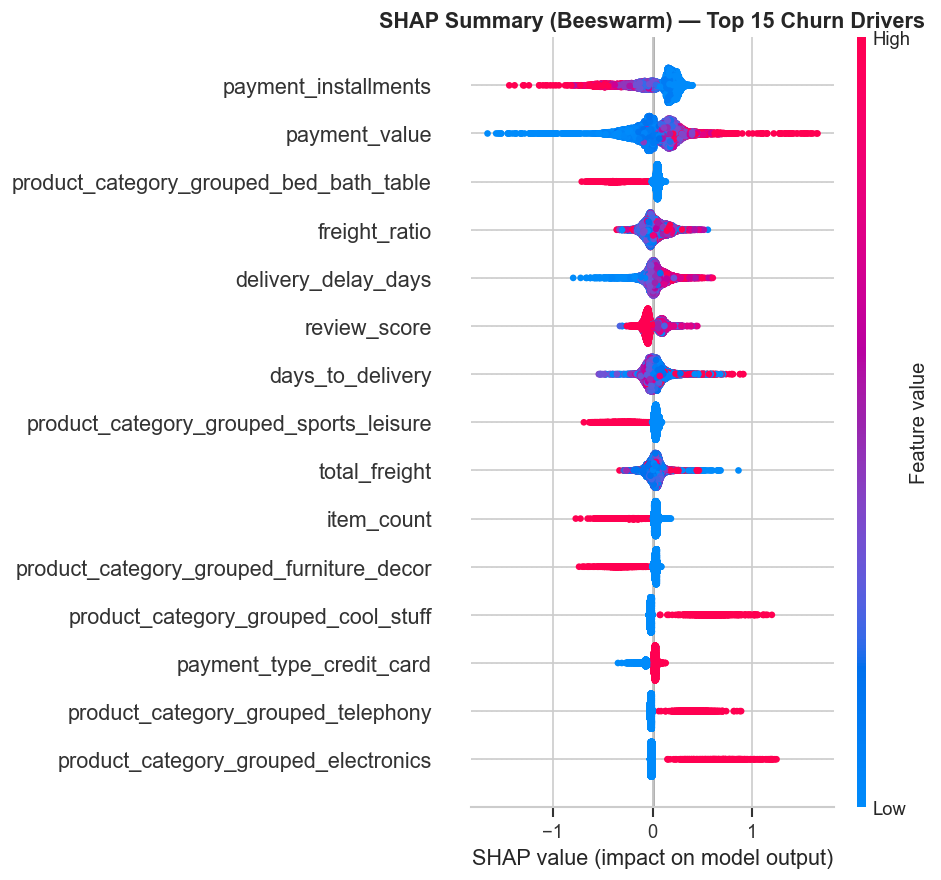

In [52]:
# SHAP Beeswarm (summary) plot — top 15 features
# Each dot = one test observation
# Colour = feature value (blue = low, red = high)
# x-axis position = SHAP impact on churn prediction
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    max_display=15,
    show=False
)
plt.title('SHAP Summary (Beeswarm) — Top 15 Churn Drivers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

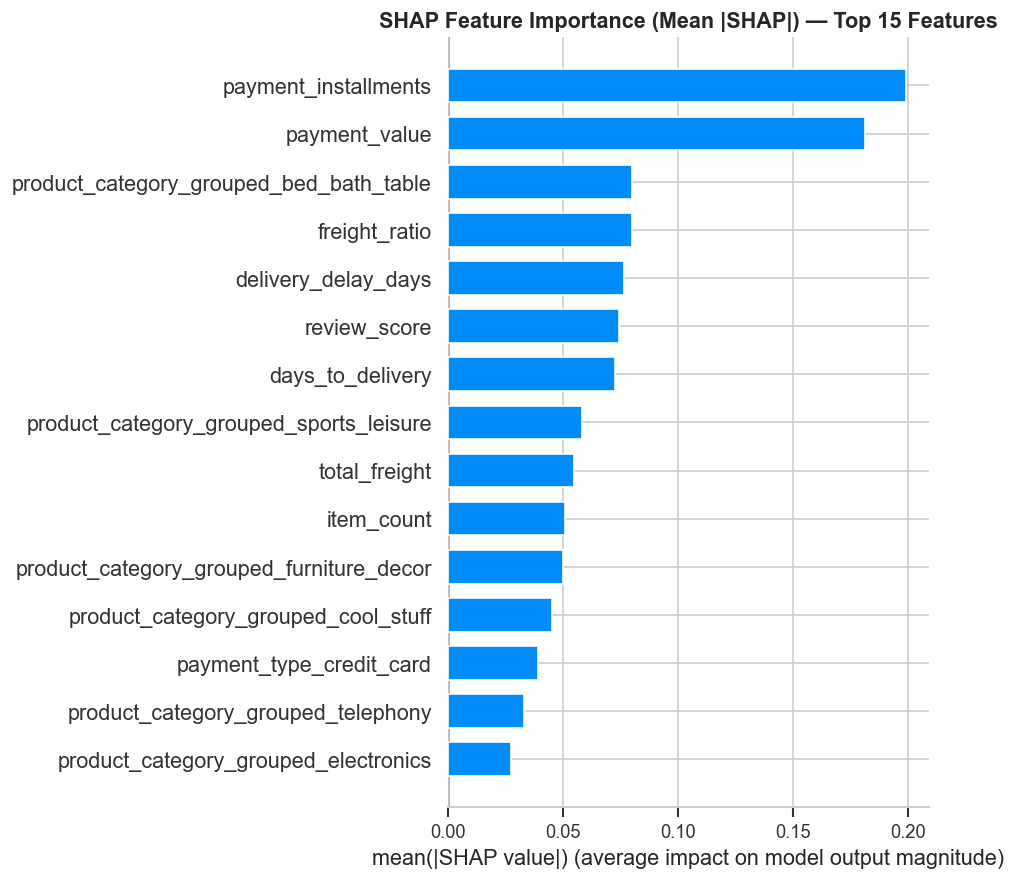

In [53]:
# SHAP Bar plot — mean absolute SHAP values (global feature importance, direction-agnostic)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP|) — Top 15 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [54]:
# Build ranked DataFrame of mean |SHAP| for all 57 features
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance_df = (
    pd.DataFrame({'feature': X_test.columns, 'mean_abs_shap': mean_abs_shap})
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)
feature_importance_df['rank'] = feature_importance_df.index + 1

print('=== Top 15 features by mean |SHAP| ===')
print(feature_importance_df.head(15).to_string(index=False))

=== Top 15 features by mean |SHAP| ===
                                 feature  mean_abs_shap  rank
                    payment_installments       0.199068     1
                           payment_value       0.181273     2
 product_category_grouped_bed_bath_table       0.080124     3
                           freight_ratio       0.079971     4
                     delivery_delay_days       0.076779     5
                            review_score       0.074231     6
                        days_to_delivery       0.072603     7
 product_category_grouped_sports_leisure       0.058319     8
                           total_freight       0.055012     9
                              item_count       0.051149    10
product_category_grouped_furniture_decor       0.049928    11
     product_category_grouped_cool_stuff       0.045513    12
                payment_type_credit_card       0.039044    13
      product_category_grouped_telephony       0.033150    14
    product_category_grouped_el

### SHAP Interpretation — Top Churn Drivers

The top churn predictors are payment_installments (rank 1), payment_value (rank 2), freight_ratio (rank 4), and delivery_delay_days (rank 5). This tells a coherent business story: a customer’s financial experience — how much they paid, how they financed it, and what share went to freight — combined with delivery reliability are the primary drivers of return behaviour. The growth team should prioritise reducing freight costs for first-time customers and improving delivery reliability over broad re-engagement campaigns.

---
## 8. Sentiment Feature Contribution

We engineered three NLP features in notebook 02: `sentiment_polarity`, `sentiment_subjectivity`, and `has_review_text`. Here we audit whether that pipeline adds predictive signal beyond the structured `review_score`.

This is an honest, quantitative answer to: *"Was the NLP work worth it as a predictive feature?"* If sentiment ranks low in SHAP importance, we explain why the LLM analysis in notebook 04 is still motivated on different grounds.

In [55]:
sentiment_features = ['sentiment_polarity', 'sentiment_subjectivity', 'has_review_text']

print(f'=== Sentiment Feature SHAP Analysis ===')
print(f'Total features: {len(feature_importance_df)}\n')

sentiment_rows = feature_importance_df[feature_importance_df['feature'].isin(sentiment_features)]
print('Sentiment features:')
print(sentiment_rows[['rank', 'feature', 'mean_abs_shap']].to_string(index=False))

print('\n=== Top 5 non-sentiment features for comparison ===')
non_sentiment = feature_importance_df[~feature_importance_df['feature'].isin(sentiment_features)]
print(non_sentiment.head(5)[['rank', 'feature', 'mean_abs_shap']].to_string(index=False))

=== Sentiment Feature SHAP Analysis ===
Total features: 57

Sentiment features:
 rank                feature  mean_abs_shap
   16        has_review_text       0.025299
   32 sentiment_subjectivity       0.004989
   39     sentiment_polarity       0.003007

=== Top 5 non-sentiment features for comparison ===
 rank                                 feature  mean_abs_shap
    1                    payment_installments       0.199068
    2                           payment_value       0.181273
    3 product_category_grouped_bed_bath_table       0.080124
    4                           freight_ratio       0.079971
    5                     delivery_delay_days       0.076779


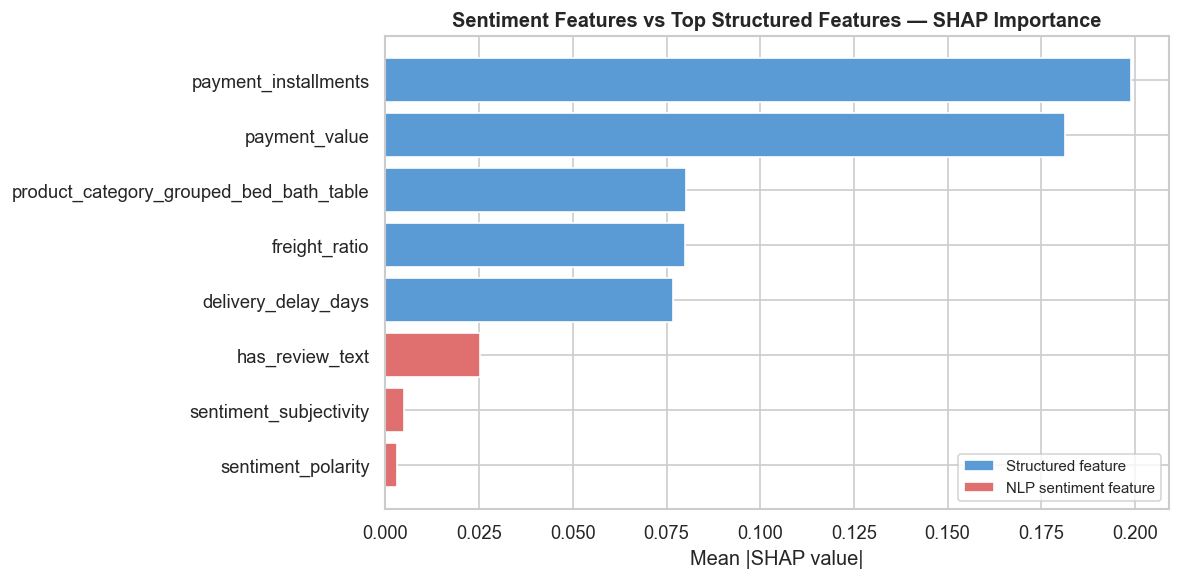

In [56]:
# Visual comparison: NLP sentiment features vs top structured features
from matplotlib.patches import Patch

top_structured = non_sentiment.head(5).copy()
plot_df = pd.concat([top_structured, sentiment_rows]).sort_values('mean_abs_shap', ascending=True)
colors  = ['#e07070' if f in sentiment_features else '#5B9BD5' for f in plot_df['feature']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(plot_df['feature'], plot_df['mean_abs_shap'], color=colors)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Sentiment Features vs Top Structured Features — SHAP Importance', fontweight='bold')
legend_elements = [
    Patch(facecolor='#5B9BD5', label='Structured feature'),
    Patch(facecolor='#e07070', label='NLP sentiment feature')
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

### Does sentiment add meaningful signal?

has_review_text ranks 16th out of 57 features (mean |SHAP| = 0.025), indicating that whether a customer left a review is a meaningful signal. sentiment_polarity ranks 39th (mean |SHAP| = 0.003) — a weak standalone predictor. This is expected: TextBlob sentiment scoring on Portuguese text is noisy, and a single polarity scalar loses the specific content of what customers wrote. This motivates the Anthropic API analysis in notebook 04, which examines the actual text of churned customer reviews to surface qualitative drivers that a polarity score cannot capture.

---
## 9. Save Model Artifacts

We persist the best model, SHAP-augmented test set, and feature importance rankings to `data/processed/`. Notebook 04 (business impact and LLM insight generation) loads these files directly.

In [57]:
import os

# 1. Save the best model
model_path = PROCESSED_DIR + 'best_model.pkl'
joblib.dump(best_model, model_path)
print(f'[1/3] Best model saved  : {model_path}')

# 2. Save X_test with SHAP values appended as extra columns
#    Column naming convention: shap_<original_feature_name>
shap_cols    = [f'shap_{col}' for col in X_test.columns]
shap_df      = pd.DataFrame(shap_values, columns=shap_cols, index=X_test.index)
X_test_shap  = pd.concat([X_test.reset_index(drop=True), shap_df.reset_index(drop=True)], axis=1)
# Append true label and predicted churn probability so notebook 04 can segment customers
X_test_shap['churned']    = y_test.values
X_test_shap['churn_prob'] = y_prob_best

shap_path = PROCESSED_DIR + 'X_test_shap.csv'
X_test_shap.to_csv(shap_path, index=False)
print(f'[2/3] X_test + SHAP saved: {shap_path}  (shape: {X_test_shap.shape})')

# 3. Save feature importance (feature name + mean |SHAP|, sorted descending)
fi_path = PROCESSED_DIR + 'feature_importance.csv'
feature_importance_df.to_csv(fi_path, index=False)
print(f'[3/3] Feature importance : {fi_path}  ({len(feature_importance_df)} features)')

print('\n=== All artifacts saved successfully ===')
print(f'  Model            : {best_model_name}')
print(f'  ROC-AUC (test)   : {results[best_model_name]["ROC-AUC"]:.4f}')
print(f'  F1 (retained)    : {results[best_model_name]["F1_ret"]:.4f}')
print(f'  Optimal threshold: {best_threshold:.4f}')

[1/3] Best model saved  : ../data/processed/best_model.pkl
[2/3] X_test + SHAP saved: ../data/processed/X_test_shap.csv  (shape: (14093, 116))
[3/3] Feature importance : ../data/processed/feature_importance.csv  (57 features)

=== All artifacts saved successfully ===
  Model            : XGBoost
  ROC-AUC (test)   : 0.6327
  F1 (retained)    : 0.1625
  Optimal threshold: 0.5337
